Persiapan dataset comparasi



In [ ]:
# ==========================================
# BAGIAN 1: PREPROCESSING DATA LOG -> TF-IDF
# ==========================================
import pandas as pd
import numpy as np
import json
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from google.colab import files
from IPython.display import display

file_path = '/content/wazuh_formatted_alerts (1).json'
output_csv_path = '/content/blablaboa_TFIDF_LowCard_ML.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError(f"File tidak ditemukan: {file_path}")

# 1. BACA & FLATTEN DATA
with open(file_path, 'r', encoding='utf-8') as f:
    try:
        data_list = json.load(f)
    except json.JSONDecodeError:
        f.seek(0)
        data_list = [json.loads(line) for line in f if line.strip()]

df = pd.DataFrame(data_list)

if 'input' in df.columns:
    df['input_parsed'] = df['input'].apply(json.loads)
    input_df = pd.json_normalize(df['input_parsed'])
    cols_to_keep = [col for col in df.columns if col not in ['input', 'input_parsed']]
    df = pd.concat([df[cols_to_keep], input_df], axis=1)

# Amankan kolom yang berisi List/Dictionary
for col in df.select_dtypes(include=['object']).columns:
    if col != 'target' and not col.startswith('tfidf_svd_'):
        df[col] = df[col].fillna('').apply(lambda x: ','.join(map(str, x)) if isinstance(x, list) else str(x))

# Encode Target
target_map = {'false positive': 0, 'False Positive': 0, 'true positive': 1, 'True Positive': 1}
df['target'] = df['output'].map(target_map).fillna(0).astype(int)
df = df.drop(columns=['output'], errors='ignore')

print(f"📊 Data awal: {df.shape[0]} baris, {df.shape[1]} kolom.")

# ==========================================
# 2. DROP ID, INSTRUKSI, & HIGH CARDINALITY
# ==========================================
cols_to_drop = [
    'instruction', 'id',
    'rule.id', 'rule.firedtimes', 'rule.level', 'rule.groups',
    'rule.mail', 'rule.mitre.tactic', 'rule.mitre.technique', 'rule.mitre.id',
    'rule.gdpr', 'rule.gpg13', 'rule.pci_dss', 'rule.nist_800_53',  # <-- TAMBAHKAN
    'decoder.name', 'decoder.parent',  # <-- CONTEKAN UTAMA!
    'data.id', 'data.command',  # <-- CONTEKAN BESAR!
    'data.srcip', 'data.srcport', 'data.srcuser', 'data.dstuser',
    'data.uid', 'data.tty', 'data.pwd', 'data.url',
    'data.vulnerability.cve', 'data.vulnerability.package.name',
    'data.vulnerability.package.version', 'data.vulnerability.reference',
    'data.vulnerability.title',
    'decoder.ftscomment', 'predecoder.timestamp',
    'data.version', 'data.origin.name', 'data.origin.module',
    'location', 'timestamp', 'rule.tsc'  # <-- Mungkin juga bermasalah
]

df = df.drop(columns=cols_to_drop, errors='ignore')
df = df.drop(columns=[col for col in df.columns if col.startswith('data.parameters.')], errors='ignore')

for col in df.columns:
    if col != 'target' and col not in ['full_log', 'rule.description'] and df[col].nunique() <= 1:
        print(f"💡 Dropping constant/masked column: {col}")
        df = df.drop(columns=[col])

print(f"✂️ Setelah drop high cardinality & ID: {df.shape[1]} kolom tersisa.")

# ==========================================
# 3. TF-IDF VECTORIZATION + SVD REDUCTION
# ==========================================
print("\n📝 Memproses Teks dengan TF-IDF...")

df['rule.description'] = df['rule.description'].fillna('No description').astype(str)
df['full_log'] = df['full_log'].fillna('No log available').astype(str)

text_to_vectorize = df['rule.description'] + " [LOG] " + df['full_log']

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),       # Unigram + Bigram (penting untuk log security)
    sublinear_tf=True,
    min_df=2,
    dtype=np.float32
)

print("🔄 Menggenerate Matriks TF-IDF (Sparse)...")
tfidf_matrix = vectorizer.fit_transform(text_to_vectorize)
print(f"✅ Matriks TF-IDF mentah terbentuk: {tfidf_matrix.shape[1]} fitur unik.")

print("🔄 Melakukan reduksi dimensi dengan TruncatedSVD (LSA)...")
svd = TruncatedSVD(n_components=100, random_state=42)
svd_features = svd.fit_transform(tfidf_matrix)

svd_cols = [f'tfidf_svd_{i}' for i in range(svd_features.shape[1])]
svd_df = pd.DataFrame(svd_features, columns=svd_cols)

df = pd.concat([df, svd_df], axis=1)
df = df.drop(columns=['full_log', 'rule.description'], errors='ignore')
print(f"✅ Berhasil menambahkan {svd_features.shape[1]} kolom TF-IDF (hasil reduksi SVD)!")

# ==========================================
# 4. HANDLE SISA KOLOM KATEGORIKAL & NUMERIK
# ==========================================
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns
categorical_cols = [col for col in categorical_cols if col != 'target']

print(f"🔄 Melakukan Label Encoding pada {len(categorical_cols)} kolom kategorikal sisa...")
for col in categorical_cols:
    df[col] = df[col].fillna('Missing').astype(str)
    df[col] = LabelEncoder().fit_transform(df[col])

numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col != 'target' and not col.startswith('tfidf_svd_')]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df['target'] = df['target'].astype(int)
# Di bagian cols_to_drop, tambahkan:
additional_drops = [
    'decoder.name', 'decoder.parent',
    'data.command',
    'rule.gdpr', 'rule.gpg13', 'rule.pci_dss', 'rule.nist_800_53',
    'location', 'timestamp', 'rule.tsc'
]

df = df.drop(columns=additional_drops, errors='ignore')
print(f"✅ Ditambahkan {len(additional_drops)} fitur ke dalam drop list")
print(f"📊 Kolom tersisa: {df.shape[1]}")
# ==========================================
# 5. SIMPAN & DOWNLOAD
# ==========================================
cols = [col for col in df.columns if col != 'target'] + ['target']
df = df[cols]

df.to_csv(output_csv_path, index=False, encoding='utf-8')

print(f"\n✅ Data dengan TF-IDF & Low-Cardinality siap ML disimpan: {output_csv_path}")
print(f"📊 Dimensi akhir: {df.shape[0]} baris, {df.shape[1]} kolom.")

print("\n--- Kolom Tabular yang Dipertahankan ---")
tabular_cols = [col for col in df.columns if not col.startswith('tfidf_svd_') and col != 'target']
print(tabular_cols)

print("\n--- Preview 3 Baris Pertama ---")
display(df.head(3))

print("\n⬇️ Mengunduh file CSV...")
files.download(output_csv_path)

📊 Data awal: 738 baris, 97 kolom.
💡 Dropping constant/masked column: agent.id
💡 Dropping constant/masked column: agent.name
💡 Dropping constant/masked column: agent.ip
💡 Dropping constant/masked column: manager.name
✂️ Setelah drop high cardinality & ID: 18 kolom tersisa.

📝 Memproses Teks dengan TF-IDF...
🔄 Menggenerate Matriks TF-IDF (Sparse)...
✅ Matriks TF-IDF mentah terbentuk: 4762 fitur unik.
🔄 Melakukan reduksi dimensi dengan TruncatedSVD (LSA)...
✅ Berhasil menambahkan 100 kolom TF-IDF (hasil reduksi SVD)!
🔄 Melakukan Label Encoding pada 15 kolom kategorikal sisa...
✅ Ditambahkan 10 fitur ke dalam drop list
📊 Kolom tersisa: 116

✅ Data dengan TF-IDF & Low-Cardinality siap ML disimpan: /content/blablaboa_TFIDF_LowCard_ML.csv
📊 Dimensi akhir: 738 baris, 116 kolom.

--- Kolom Tabular yang Dipertahankan ---
['rule.hipaa', 'predecoder.program_name', 'predecoder.hostname', 'data.protocol', 'data.vulnerability.classification', 'data.vulnerability.enumeration', 'data.vulnerability.pack

,rule.hipaa,predecoder.program_name,predecoder.hostname,data.protocol,data.vulnerability.classification,data.vulnerability.enumeration,data.vulnerability.package.architecture,data.vulnerability.published,data.vulnerability.score.base,data.vulnerability.score.version,...,tfidf_svd_91,tfidf_svd_92,tfidf_svd_93,tfidf_svd_94,tfidf_svd_95,tfidf_svd_96,tfidf_svd_97,tfidf_svd_98,tfidf_svd_99,target
0,1,0,0,0,0,0,0,0,0,0,...,0.001460,-0.000336,0.000949,0.000554,-0.000630,0.000863,0.002481,-0.001678,0.000787,0
1,1,0,0,0,0,0,0,0,0,0,...,-0.000933,-0.000718,0.003479,-0.001868,0.000569,-0.000165,0.000027,0.001890,-0.001979,0
2,1,0,0,0,0,0,0,0,0,0,...,-0.000641,-0.000508,0.000744,-0.000468,-0.001729,0.000772,0.000790,-0.002634,-0.000044,0



⬇️ Mengunduh file CSV...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

comparasi


📊 Distribusi Kelas (Natural Imbalance):
Kelas 0 (Alarm Palsu): 499 (67.6%)
Kelas 1 (Serangan)   : 239 (32.4%)
--------------------------------------------------
🚀 Memulai 5-Fold Cross-Validation (Tanpa Balancing)...

🔹 Training Random Forest...
   📂 Fold 1/5 | F1: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | Time: 0.53s
   📂 Fold 2/5 | F1: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | Time: 0.48s
   📂 Fold 3/5 | F1: 0.9895 | Prec: 1.0000 | Rec: 0.9792 | Time: 0.47s
   📂 Fold 4/5 | F1: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | Time: 0.46s
   📂 Fold 5/5 | F1: 0.9787 | Prec: 1.0000 | Rec: 0.9583 | Time: 0.46s
   ✅ Rata-rata Random Forest | F1: 0.9936 (±0.0085)

🔹 Training XGBoost...
   📂 Fold 1/5 | F1: 0.9796 | Prec: 0.9600 | Rec: 1.0000 | Time: 0.16s
   📂 Fold 2/5 | F1: 0.9897 | Prec: 0.9796 | Rec: 1.0000 | Time: 0.20s
   📂 Fold 3/5 | F1: 0.9895 | Prec: 1.0000 | Rec: 0.9792 | Time: 0.18s
   📂 Fold 4/5 | F1: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | Time: 0.17s
   📂 Fold 5/5 | F1: 0.9787 | Prec: 1.0000 | Rec: 0

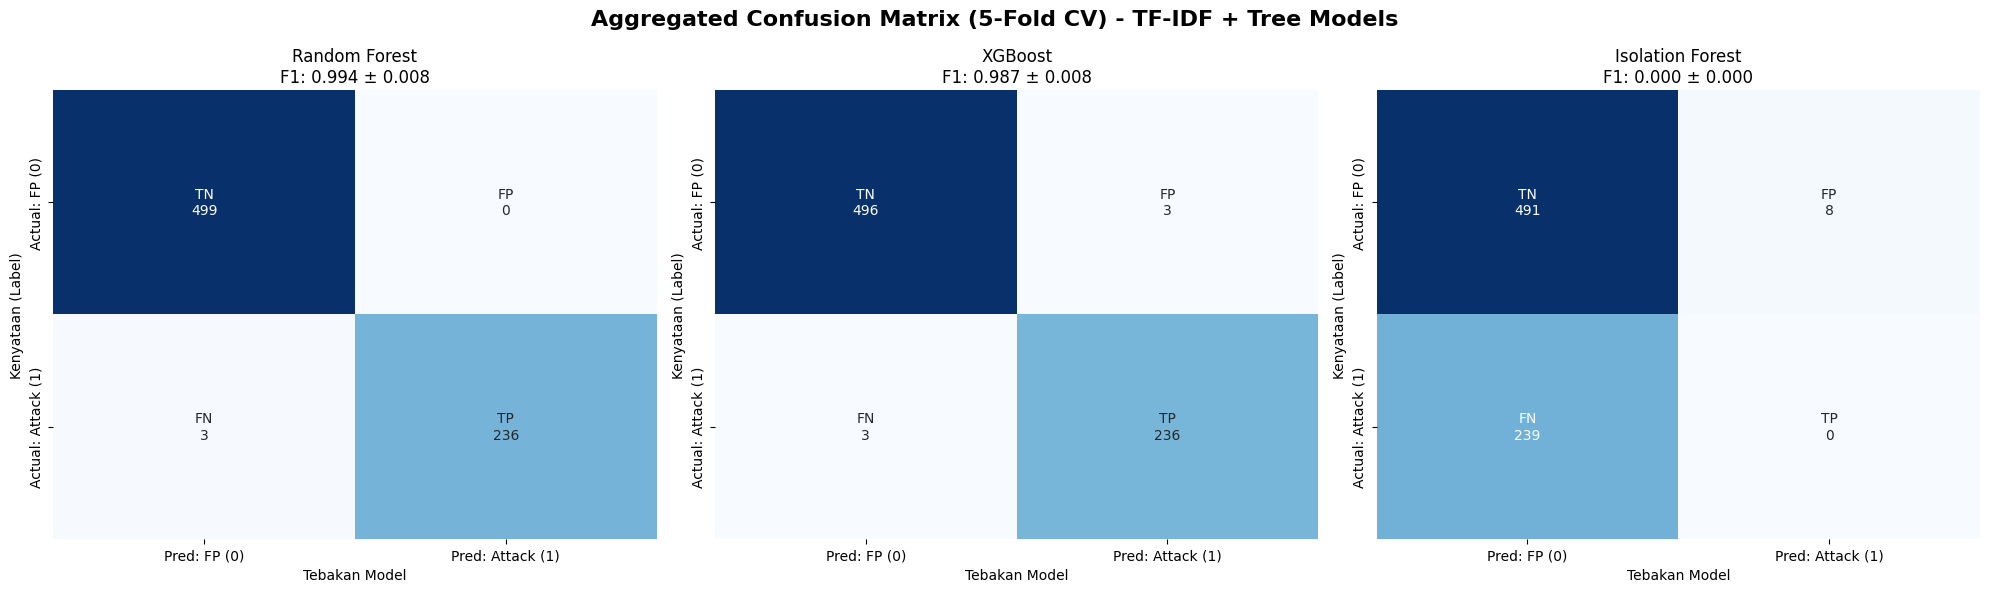

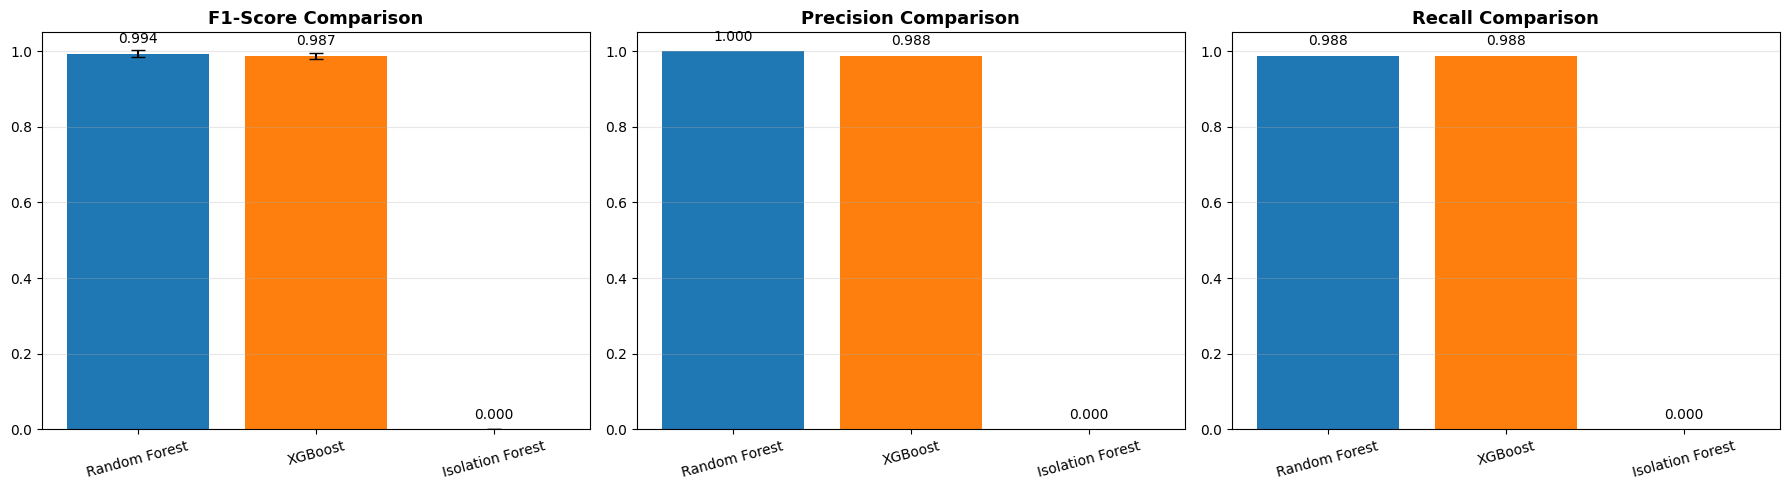


📊 Ringkasan 5-Fold Cross-Validation (TF-IDF + Natural Imbalance):


,Model,F1-Score (mean ± std),Precision,Recall,Total Time (s)
0,Random Forest,0.9936 ± 0.0085,1.0000,0.9875,2.40
1,XGBoost,0.9875 ± 0.0078,0.9879,0.9875,0.94
2,Isolation Forest,0.0000 ± 0.0000,0.0000,0.0000,1.65



🔍 VERIFIKASI: Cek apakah 'contekan' sudah hilang


<Figure size 1200x800 with 0 Axes>

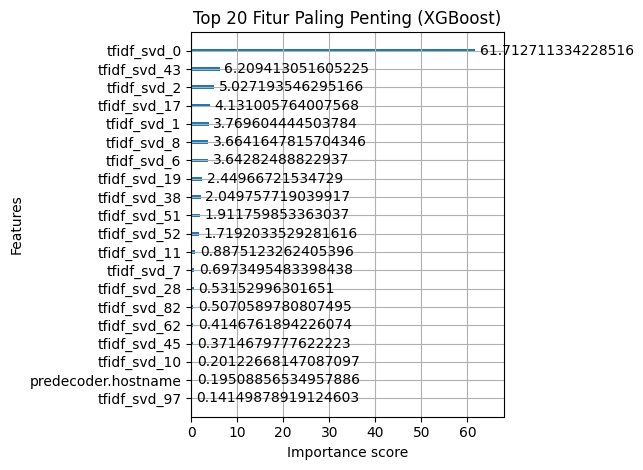


🔍 10 Fitur Tabular dengan Korelasi Tertinggi terhadap Target:
predecoder.hostname                        0.875790
rule.hipaa                                 0.831295
predecoder.program_name                    0.805926
data.protocol                              0.273272
data.vulnerability.enumeration             0.088976
data.vulnerability.package.architecture    0.088976
data.vulnerability.type                    0.088976
data.vulnerability.status                  0.088976
data.vulnerability.classification          0.085564
data.vulnerability.published               0.085564
dtype: float64

✅ SUKSES: rule.level sudah dihapus. Model sekarang belajar dari pola teks log yang sebenarnya.

💡 Interpretasi:
   - Jika fitur teratas adalah 'tfidf_svd_*' -> Model belajar dari pola teks (BAGUS!)
   - Jika fitur teratas adalah metadata seperti 'rule.level' -> Masih ada data leakage
   - F1-Score yang turun dari 1.0000 adalah tanda model yang sehat dan realistis


In [ ]:
# ==========================================
# BAGIAN 2: TRAINING K-FOLD CV & EVALUASI
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import xgboost as xgb
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD DATA
df = pd.read_csv('/content/blablaboa_TFIDF_LowCard_ML.csv')
X = df.drop(columns=['target'])
y = df['target']

print(f"📊 Distribusi Kelas (Natural Imbalance):")
print(f"Kelas 0 (Alarm Palsu): {len(y) - y.sum()} ({((len(y) - y.sum())/len(y)*100):.1f}%)")
print(f"Kelas 1 (Serangan)   : {y.sum()} ({(y.sum()/len(y)*100):.1f}%)")
print("-" * 50)

# 2. INISIALISASI MODEL & K-FOLD
N_SPLITS = 5

models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    "Isolation Forest": IsolationForest(random_state=42, contamination='auto', n_jobs=-1)
}

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

results = {name: {
    'f1': [], 'prec': [], 'rec': [], 'time': [],
    'cm_agg': np.zeros((2, 2), dtype=int)
} for name in models.keys()}

print(f"🚀 Memulai {N_SPLITS}-Fold Cross-Validation (Tanpa Balancing)...\n")

# 3. TRAINING & EVALUASI PER FOLD
for name, model in models.items():
    print(f"🔹 Training {name}...")
    fold_times = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # SCALING: Fit HANYA pada train fold untuk mencegah data leakage
        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc = scaler.transform(X_test)

        start_time = time.time()

        if name == "Isolation Forest":
            model.fit(X_train_sc)
            y_pred = model.predict(X_test_sc)
            y_pred = np.where(y_pred == -1, 1, 0)
        else:
            model.fit(X_train_sc, y_train)
            y_pred = model.predict(X_test_sc)

        fold_time = time.time() - start_time
        fold_times.append(fold_time)

        cm = confusion_matrix(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)

        results[name]['f1'].append(f1)
        results[name]['prec'].append(prec)
        results[name]['rec'].append(rec)
        results[name]['time'].append(fold_time)
        results[name]['cm_agg'] += cm

        print(f"   📂 Fold {fold}/{N_SPLITS} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | Time: {fold_time:.2f}s")

    results[name]['f1_mean'] = np.mean(results[name]['f1'])
    results[name]['f1_std'] = np.std(results[name]['f1'])
    results[name]['prec_mean'] = np.mean(results[name]['prec'])
    results[name]['rec_mean'] = np.mean(results[name]['rec'])
    results[name]['time_total'] = sum(fold_times)

    print(f"   ✅ Rata-rata {name} | F1: {results[name]['f1_mean']:.4f} (±{results[name]['f1_std']:.4f})\n")

# 4. VISUALISASI CONFUSION MATRIX (AGREGAT)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Aggregated Confusion Matrix ({N_SPLITS}-Fold CV) - TF-IDF + Tree Models',
             fontsize=16, fontweight='bold')

for i, (name, res) in enumerate(results.items()):
    cm = res['cm_agg']
    annot = np.empty_like(cm).astype(str)
    annot[0, 0] = f"TN\n{cm[0, 0]}"
    annot[0, 1] = f"FP\n{cm[0, 1]}"
    annot[1, 0] = f"FN\n{cm[1, 0]}"
    annot[1, 1] = f"TP\n{cm[1, 1]}"

    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Pred: FP (0)', 'Pred: Attack (1)'],
                yticklabels=['Actual: FP (0)', 'Actual: Attack (1)'])

    axes[i].set_title(f'{name}\nF1: {res["f1_mean"]:.3f} ± {res["f1_std"]:.3f}', fontsize=12)
    axes[i].set_xlabel('Tebakan Model', fontsize=10)
    axes[i].set_ylabel('Kenyataan (Label)', fontsize=10)

plt.tight_layout()
plt.show()

# 5. VISUALISASI PERBANDINGAN METRIK
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [
    ('F1-Score', 'f1_mean', 'f1_std'),
    ('Precision', 'prec_mean', None),
    ('Recall', 'rec_mean', None)
]

model_names = list(results.keys())
x_pos = np.arange(len(model_names))

for idx, (metric_name, mean_key, std_key) in enumerate(metrics):
    means = [results[m][mean_key] for m in model_names]

    if std_key:
        stds = [results[m][std_key] for m in model_names]
        bars = axes[idx].bar(x_pos, means, yerr=stds, capsize=5, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    else:
        bars = axes[idx].bar(x_pos, means, color=['#1f77b4', '#ff7f0e', '#2ca02c'])

    axes[idx].set_title(f'{metric_name} Comparison', fontsize=13, fontweight='bold')
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(model_names, rotation=15)
    axes[idx].set_ylim(0, 1.05)
    axes[idx].grid(axis='y', alpha=0.3)

    for bar, mean in zip(bars, means):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                      f'{mean:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 6. TABEL RINGKASAN
summary_df = pd.DataFrame([
    {
        'Model': name,
        'F1-Score (mean ± std)': f"{res['f1_mean']:.4f} ± {res['f1_std']:.4f}",
        'Precision': f"{res['prec_mean']:.4f}",
        'Recall': f"{res['rec_mean']:.4f}",
        'Total Time (s)': f"{res['time_total']:.2f}"
    }
    for name, res in results.items()
])

print(f"\n📊 Ringkasan {N_SPLITS}-Fold Cross-Validation (TF-IDF + Natural Imbalance):")
display(summary_df)

# ==========================================
# BAGIAN 3: VERIFIKASI DATA LEAKAGE (PENTING!)
# ==========================================
print("\n" + "="*60)
print("🔍 VERIFIKASI: Cek apakah 'contekan' sudah hilang")
print("="*60)

# Train XGBoost di seluruh data untuk analisis feature importance
xgb_final = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
xgb_final.fit(X, y)

# Plot Feature Importance
plt.figure(figsize=(12, 8))
xgb.plot_importance(xgb_final, max_num_features=20, importance_type='gain',
                    title='Top 20 Fitur Paling Penting (XGBoost)')
plt.tight_layout()
plt.show()

# Cek korelasi fitur tabular dengan target
tabular_cols = [col for col in X.columns if not col.startswith('tfidf_svd_')]
if tabular_cols:
    correlations = X[tabular_cols].corrwith(y).abs().sort_values(ascending=False)
    print("\n🔍 10 Fitur Tabular dengan Korelasi Tertinggi terhadap Target:")
    print(correlations.head(10))
else:
    print("\n✅ Tidak ada fitur tabular tersisa (semua sudah di-drop atau di-embed).")

# Cek apakah rule.level masih ada
if 'rule.level' in X.columns:
    print("\n⚠️ PERINGATAN: rule.level MASIH ADA di data! Data leakage belum teratasi.")
else:
    print("\n✅ SUKSES: rule.level sudah dihapus. Model sekarang belajar dari pola teks log yang sebenarnya.")

print("\n💡 Interpretasi:")
print("   - Jika fitur teratas adalah 'tfidf_svd_*' -> Model belajar dari pola teks (BAGUS!)")
print("   - Jika fitur teratas adalah metadata seperti 'rule.level' -> Masih ada data leakage")
print("   - F1-Score yang turun dari 1.0000 adalah tanda model yang sehat dan realistis")